# NB01 - Regresión logística desde cero

**Objetivos de aprendizaje**

- Entender por qué una recta no es una buena función de probabilidad.
- Conectar sigmoide, odds, log-odds y logit.
- Derivar la log-verosimilitud y la log-loss binaria.
- Implementar descenso de gradiente en NumPy.
- Comparar la implementación manual con scikit-learn.

**Referencias de este notebook**

- Berkson (1944): introduce el término logit y la función logística en bioensayo.
- Cox (1958): formaliza la regresión para respuestas binarias.
- Agresti (2013): desarrolla la interpretación de coeficientes como log-odds y odds ratios.
- Bishop (2006): presenta la regresión logística como clasificador probabilístico discriminativo.


In [1]:
%matplotlib inline
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('png')
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# Los notebooks pueden ejecutarse desde la raiz del repo o desde notebooks/.
# Este bloque localiza la raiz y agrega src/ al path de importacion.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from utils import (
    COLOR_PALETTE,
    RANDOM_STATE,
    get_train_test_split,
    load_binary_iris,
    load_processed_splits,
    plot_coefficients,
    plot_decision_boundary,
    plot_regularization_path,
    plot_sigmoid,
    save_processed_splits,
    set_plot_style,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
set_plot_style()
np.random.seed(RANDOM_STATE)

DATA_DIR = PROJECT_ROOT / "data" / "processed"

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import log_loss
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


## 1. El problema: la regresión lineal no es una probabilidad

Una regresión lineal puede producir valores menores que 0 o mayores que 1. Para clasificación binaria necesitamos una función que siempre viva en `[0, 1]` y que sea interpretable como probabilidad.


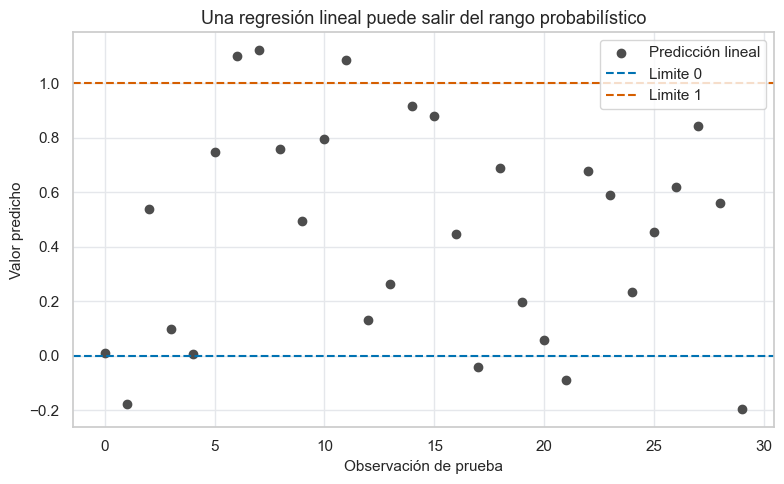

In [2]:
# Cargamos los splits compartidos generados por NB00.
data = load_processed_splits(DATA_DIR)
X_train = data["X_train"]
X_test = data["X_test"]
X_train_scaled = data["X_train_scaled"]
X_test_scaled = data["X_test_scaled"]
y_train = data["y_train"]
y_test = data["y_test"]
feature_names = data["feature_names"]

# Ajustamos una regresión lineal solo como contraejemplo pedagógico.
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
linear_predictions = linear_model.predict(X_test_scaled)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(range(len(linear_predictions)), linear_predictions, color=COLOR_PALETTE["neutral"], label="Predicción lineal")
ax.axhline(0, color=COLOR_PALETTE["versicolor"], linestyle="--", label="Limite 0")
ax.axhline(1, color=COLOR_PALETTE["virginica"], linestyle="--", label="Limite 1")
ax.set_title("Una regresión lineal puede salir del rango probabilístico")
ax.set_xlabel("Observación de prueba")
ax.set_ylabel("Valor predicho")
ax.legend()
fig.tight_layout()
plt.show()


**Interpretación.** Aunque en este split las predicciones pueden quedar cerca de `[0, 1]`, el modelo lineal no impone ese rango. La regresión logística resuelve el problema aplicando la función logística al predictor lineal.


## 2. Sigmoide, odds y logit

Berkson (1944) llamo `logit` al logaritmo de los odds. La sigmoide convierte cualquier log-odds real en una probabilidad: valores negativos producen probabilidades menores a 0.5 y valores positivos producen probabilidades mayores a 0.5.


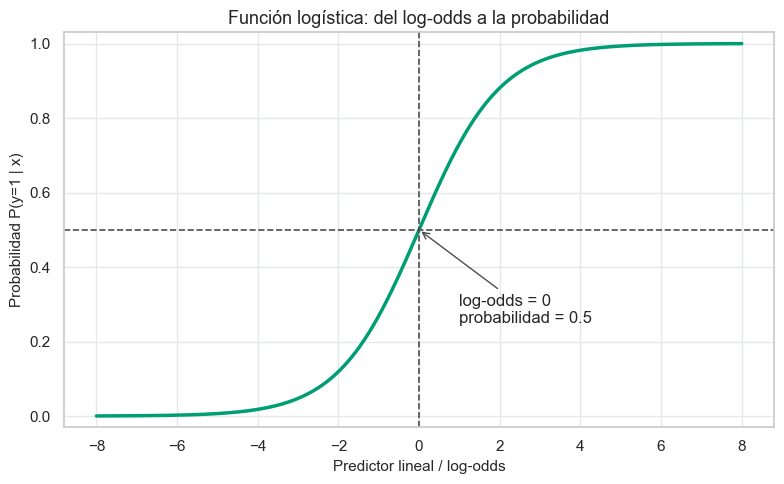

In [3]:
# La función helper anota el punto central: log-odds=0 equivale a p=0.5.
plot_sigmoid()
plt.show()


**Interpretación.** La curva muestra la idea central: el modelo puede ser lineal en log-odds y no lineal en probabilidad. Esto permite interpretar coeficientes lineales sin perder la restriccion probabilística.


## 3. Modelo e interpretación

El modelo es `P(y=1|x) = sigmoid(beta0 + beta^T x)`. Un coeficiente aumenta o disminuye el log-odds de `virginica`; su exponencial es un odds ratio. Agresti (2013) usa esta escala para interpretar efectos en datos categóricos.


## 4. Máxima verosimilitud y log-loss

Cox (1958) formalizó la regresión para datos binarios mediante verosimilitud. Para observaciones independientes, la log-verosimilitud es la suma de `y log(p) + (1-y) log(1-p)`. Minimizar la log-loss es equivalente a maximizar esa log-verosimilitud. No hay solución cerrada general, por lo que usamos optimización iterativa.

**Valores numéricos del descenso de gradiente.** `learning_rate=0.15` es deliberadamente moderado: suficientemente grande para converger en pocas miles de iteraciones, pero no tan grande como para oscilar. `n_iterations=6000` deja una curva de pérdida estable y comparable con scikit-learn; en un dataset de 70 observaciones el costo computacional sigue siendo trivial.


In [4]:
def sigmoid(z):
    # Convertimos el predictor lineal en probabilidades. El clipping
    # numérico evita overflow si z toma valores extremos.
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))


def add_intercept(X_array):
    # Agregamos una columna de unos para estimar beta0 junto con beta.
    return np.c_[np.ones(X_array.shape[0]), X_array]


def binary_log_loss(y_true, y_prob):
    # La log-loss negativa es la función de costo que minimizamos.
    eps = 1e-12
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))


# Matrices NumPy para una implementación desde cero y reproducible.
X_design = add_intercept(X_train_scaled.to_numpy())
y_array = y_train.to_numpy()

beta = np.zeros(X_design.shape[1])
# learning_rate controla el tamaño de cada paso: 0.15 converge rápido sin saltar el mínimo.
learning_rate = 0.15
# 6000 iteraciones permiten ver una convergencia suave en este dataset pequeño.
n_iterations = 6000
losses = []

for iteration in range(n_iterations):
    # Paso forward: probabilidad estimada para cada flor.
    logits = X_design @ beta
    probabilities = sigmoid(logits)

    # Gradiente de la log-loss promedio: X^T(p-y)/n.
    gradient = X_design.T @ (probabilities - y_array) / len(y_array)

    # Paso de descenso: nos movemos contra el gradiente.
    beta -= learning_rate * gradient

    if iteration % 20 == 0:
        losses.append(binary_log_loss(y_array, sigmoid(X_design @ beta)))

coeficientes_manual = pd.Series(beta[1:], index=feature_names, name="coeficiente_manual")
intercepto_manual = beta[0]
print(f"Intercepto manual: {intercepto_manual:.4f}")
display(coeficientes_manual.to_frame().round(4))


Intercepto manual: 0.4829


,coeficiente_manual
sepal length (cm),-0.7105
sepal width (cm),-0.8780
petal length (cm),4.3087
petal width (cm),5.7835


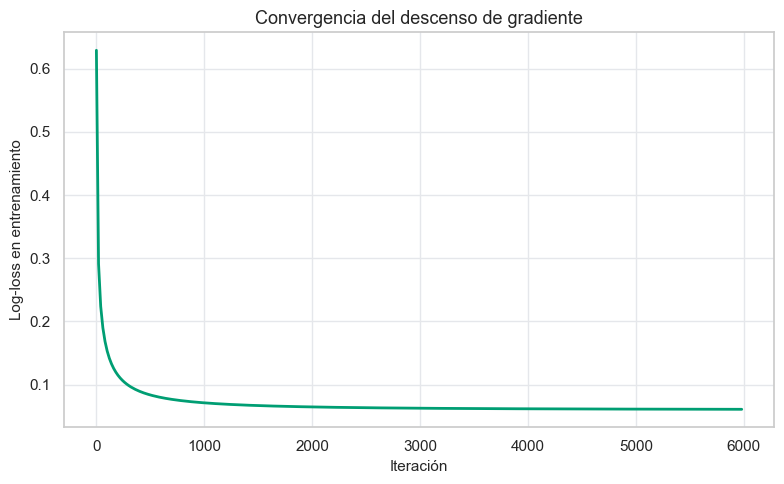

In [5]:
# La curva de pérdida verifica que la optimización realmente converge.
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.arange(len(losses)) * 20, losses, color=COLOR_PALETTE["decision"], linewidth=2)
ax.set_title("Convergencia del descenso de gradiente")
ax.set_xlabel("Iteración")
ax.set_ylabel("Log-loss en entrenamiento")
fig.tight_layout()
plt.show()


**Interpretación.** La pérdida cae rápidamente y luego se aplana. Ese patrón indica que el gradiente está encontrando una región cercana al óptimo de máxima verosimilitud.


## 5. Comparación con scikit-learn

Bishop (2006) presenta la regresión logística como un clasificador probabilístico discriminativo. scikit-learn implementa esa idea con solvers robustos; aquí usamos `C` enorme para que la regularización sea casi nula y la comparación con MLE sea justa.

**Hiperparámetros de comparación.** `C=1e6` hace que la penalización L2 sea casi nula porque `C` controla de forma inversa la fuerza de regularización en scikit-learn. La constante exacta depende de cómo se normaliza el objetivo, pero pedagógicamente un `C` enorme aproxima el MLE sin regularización. `solver='lbfgs'` es adecuado para problemas pequeños y suaves con L2; `max_iter=5000` solo evita cortar la optimización antes de converger.


In [6]:
# C=1e6 deja una penalización L2 prácticamente nula para comparar con MLE.
# lbfgs resuelve bien este problema suave; max_iter=5000 es margen de convergencia, no tuning predictivo.
sklearn_model = LogisticRegression(C=1e6, solver="lbfgs", max_iter=5000, random_state=RANDOM_STATE)
sklearn_model.fit(X_train_scaled, y_train)

comparacion = pd.DataFrame(
    {
        "manual": beta[1:],
        "sklearn_C_muy_grande": sklearn_model.coef_.ravel(),
        "diferencia_abs": np.abs(beta[1:] - sklearn_model.coef_.ravel()),
    },
    index=feature_names,
)
display(comparacion.round(4))
print(f"Intercepto sklearn: {sklearn_model.intercept_[0]:.4f}")
print(f"Log-loss test sklearn: {log_loss(y_test, sklearn_model.predict_proba(X_test_scaled)[:, 1]):.4f}")


,manual,sklearn_C_muy_grande,diferencia_abs
sepal length (cm),-0.7105,-0.9821,0.2716
sepal width (cm),-0.8780,-0.8135,0.0645
petal length (cm),4.3087,5.0764,0.7677
petal width (cm),5.7835,6.4396,0.6561


Intercepto sklearn: 0.4788
Log-loss test sklearn: 0.0935


**Interpretación.** Los coeficientes no tienen que ser idénticos decimal por decimal porque el optimizador manual usa una tasa fija y se detiene por iteraciones. Lo importante es que signos, magnitudes relativas y log-loss coinciden razonablemente con la solución industrial.


## 6. Frontera de decisión en 2D

Para visualizar la frontera entrenamos un modelo auxiliar con `petal length` y `petal width`. Los modelos completos del curso usan las cuatro variables; este modelo 2D es solo una herramienta visual.

El modelo auxiliar 2D usa los mismos hiperparámetros (`C=1e6`, `solver='lbfgs'`, `max_iter=5000`) para que la frontera visual represente el caso casi no regularizado, no una decisión de tuning nueva.


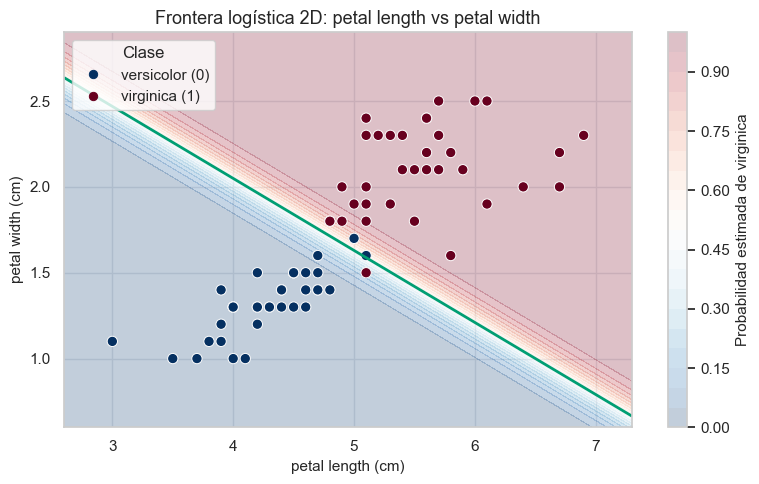

In [7]:
# Usamos pipeline para escalar dentro del modelo 2D sin alterar las
# unidades originales del gráfico.
features_2d = ["petal length (cm)", "petal width (cm)"]
model_2d = make_pipeline(
    StandardScaler(),
    LogisticRegression(C=1e6, solver="lbfgs", max_iter=5000, random_state=RANDOM_STATE),
)
model_2d.fit(X_train[features_2d], y_train)

plot_decision_boundary(
    model_2d,
    X_train[features_2d],
    y_train,
    features_2d,
    "Frontera logística 2D: petal length vs petal width",
)
plt.show()


**Interpretación.** La frontera separa regiones de alta probabilidad de `virginica` y `versicolor`, pero deja puntos cercanos a ambos lados. Esa ambigüedad es precisamente lo que la probabilidad logística representa.


## Resumen y conexion con la literatura

Berkson (1944) aporta el logit que usamos para mapear odds a una escala lineal. Cox (1958) convierte esa idea en un modelo de regresión para respuestas binarias estimado por máxima verosimilitud. Agresti (2013) justifica interpretar coeficientes como log-odds y odds ratios. Bishop (2006) conecta el mismo modelo con la visión de machine learning: un clasificador probabilístico discriminativo entrenado por optimización numérica.
